In [139]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
import torch
from dataset import DiffusionDataset, get_dataloader, sin_1d

# Generate dataset

In [140]:
# True function
def f(x):
    return 1 + np.sin(2 * np.pi * x)
# Heteroscedastic noise
def noise_std(x):
    return 0.5 + 0.4 * np.cos(6 * np.pi * x)

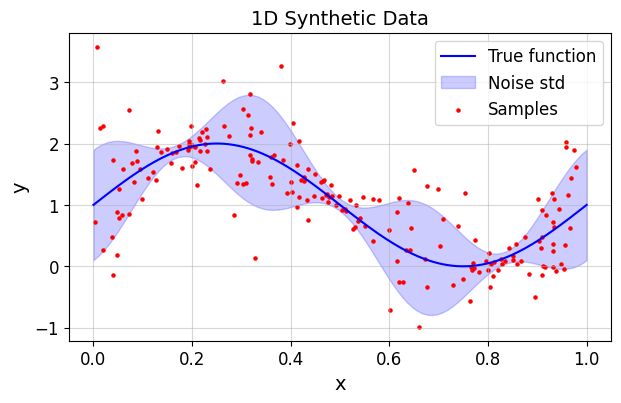

In [141]:
n = 200

# initialise graph
plt.figure(figsize=(7, 4))
plt.grid(True, alpha=0.5)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# plot true function and noise std
x = np.linspace(0, 1, 100)
plt.plot(x, f(x), 'b-', label='True function')
plt.fill_between(x, f(x) - noise_std(x), f(x) + noise_std(x), color='b', alpha=0.2, label='Noise std')

# plot sample points
x_sample = np.random.rand(n, 1) # uniformly sample 100 points from [0,1]
y_sample = f(x_sample) + np.random.randn(n, 1) * noise_std(x_sample) # get y values
plt.scatter(x_sample, y_sample, c='r', label='Samples', s=5)
plt.legend(fontsize=12)
plt.title('1D Synthetic Data', fontsize=14)
plt.show()


In [147]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
import torch
from dataset import DiffusionDataset, get_dataloader

dataset = DiffusionDataset(dataset_name='sin_1d', n_samples=3000, seed=42, x_normalise=True, y_normalise=True)
x_scalar, y_scalar = dataset.get_scalers()
train_loader, test_loader, val_loader = get_dataloader(dataset, batch_size=32, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)

# Get all x,y pairs from train_loader
train_x = []
train_y = []
for batch in train_loader:
    train_x.append(batch['X'])
    train_y.append(batch['y'])
train_x = torch.cat(train_x).squeeze()
train_y = torch.cat(train_y).squeeze()

# Get all x,y pairs from test_loader
test_x = []
test_y = []
for batch in test_loader:
    test_x.append(batch['X'])
    test_y.append(batch['y'])
test_x = torch.cat(test_x).squeeze()
test_y = torch.cat(test_y).squeeze()

# sort the pairs of train_x and train_y in ascending order based on train_x
sorted_indices = np.argsort(train_x)
train_x = train_x[sorted_indices]
train_y = train_y[sorted_indices]

# Homoscedastic GP

In [148]:
# define GP model
class ExactGPModel(gpytorch.models.ExactGP): # exactGP class provides functionality for exact GP inference (analytical posterior)
    def __init__(self, train_x, train_y, likelihood):
        """
        Methods that takes training data and likelihood as inputs,
        constructs all objects needed for the model's forward method.
        """
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood) # passes training data and likelihood to base class
        self.mean_module = gpytorch.means.ConstantMean() # defines prior mean function
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()) # defines prior covariance function
        
    def forward(self, x): # specifies how to compute the GP prior/posterior at input points x
        """
        Method that takes input x and returns a multivariate normal distribution evaluated at x.
        """
        mean_x = self.mean_module(x)  
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x) # returns multivariate normal distribution

In [149]:
# initialise likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood() # assumes homoscedastic noise
model = ExactGPModel(train_x, train_y, likelihood)

# train the model
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model) # for model hyperparameters optimization

training_iter = 100
for i in range(training_iter):
    # zero gradients from previous iteration
    optimizer.zero_grad()
    # compute output from model
    output = model(train_x) # output is a multivariate normal distribution
    # calculate log likelihood
    loss = -mll(output, train_y)
    # backpropagate
    loss.backward()
    # print progress
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
            i + 1, training_iter, loss.item(),
            model.covar_module.base_kernel.lengthscale.item(), # kernel lengthscale
            model.likelihood.noise.item() # likelihood noise
        ))
    # update parameters
    optimizer.step()

Iter 1/100 - Loss: 1.047   lengthscale: 0.693   noise: 0.693
Iter 2/100 - Loss: 1.045   lengthscale: 0.698   noise: 0.688
Iter 3/100 - Loss: 1.044   lengthscale: 0.703   noise: 0.683
Iter 4/100 - Loss: 1.042   lengthscale: 0.708   noise: 0.678
Iter 5/100 - Loss: 1.041   lengthscale: 0.713   noise: 0.673
Iter 6/100 - Loss: 1.040   lengthscale: 0.718   noise: 0.669
Iter 7/100 - Loss: 1.038   lengthscale: 0.723   noise: 0.664
Iter 8/100 - Loss: 1.037   lengthscale: 0.728   noise: 0.659
Iter 9/100 - Loss: 1.036   lengthscale: 0.733   noise: 0.654
Iter 10/100 - Loss: 1.034   lengthscale: 0.738   noise: 0.649
Iter 11/100 - Loss: 1.033   lengthscale: 0.743   noise: 0.645
Iter 12/100 - Loss: 1.032   lengthscale: 0.748   noise: 0.640
Iter 13/100 - Loss: 1.031   lengthscale: 0.752   noise: 0.635
Iter 14/100 - Loss: 1.029   lengthscale: 0.757   noise: 0.631
Iter 15/100 - Loss: 1.028   lengthscale: 0.761   noise: 0.626
Iter 16/100 - Loss: 1.027   lengthscale: 0.765   noise: 0.622
Iter 17/100 - Los

In [150]:
print(model.covar_module.base_kernel.lengthscale)
print(model.likelihood.noise)
print(model.covar_module.outputscale)
print(model.mean_module.constant.data)

# sigma_f goes to 0 as n goes to infinity
# likelihood noise goes to the true noise std as n goes to infinity

tensor([[0.7626]], grad_fn=<SoftplusBackward0>)
tensor([0.4229], grad_fn=<AddBackward0>)
tensor(0.5832, grad_fn=<SoftplusBackward0>)
tensor(-0.0934)


RMSE: 0.8929297924041748


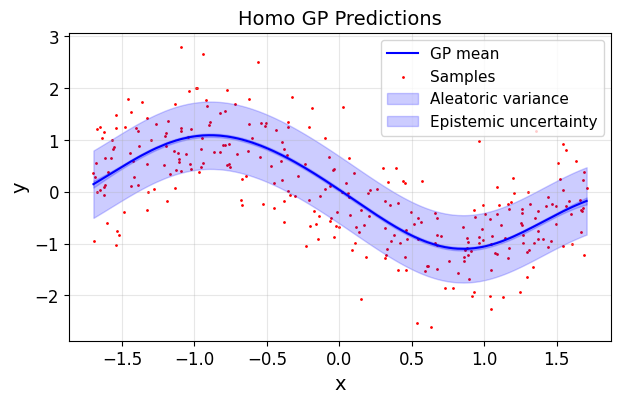

In [155]:
model.eval()
likelihood.eval()
sorted_indices = np.argsort(test_x)
test_x = test_x[sorted_indices]
test_y = test_y[sorted_indices]

f_preds = model(test_x) # distribution of noiseless predictions, f(x)
y_preds = likelihood(f_preds) # distribution of noisy predictions, y = f(x) + noise
# statistics of the distributions
f_means = f_preds.mean.detach().numpy() # GP posterior mean of the function
f_vars = f_preds.variance.detach().numpy() # GP posterior variance of the function, epistemic uncertainty
y_vars = y_preds.variance.detach().numpy()  # GP posterior variance + likelihood variance
aleatoric_vars = y_vars - f_vars
# compare the learnt f_means with the true function

samples = torch.tensor(f_means) + torch.randn_like(torch.tensor(f_means)) * torch.sqrt(torch.tensor(aleatoric_vars))
rmse = torch.sqrt(torch.mean((samples - test_y)**2))
print(f"RMSE: {rmse.item()}")

plt.figure(figsize=(7, 4))
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.plot(test_x, f_means, 'b-', label='GP mean')
plt.scatter(test_x, samples, c='r', label='Samples', s=1)
# fill between with y_vars standard deviation
plt.fill_between(test_x, f_means - np.sqrt(aleatoric_vars), f_means + np.sqrt(aleatoric_vars), color='b', alpha=0.2, label='Aleatoric variance')
# fill between epistemic uncertainty
plt.fill_between(test_x, f_means - np.sqrt(f_vars), f_means + np.sqrt(f_vars), color='b', alpha=0.2, label='Epistemic uncertainty')
# plt.plot(test_x, f(test_x), 'r-', label='True function')
# plt.fill_between(test_x, f(test_x) - np.sqrt(noise_std(test_x)**2), f(test_x) + np.sqrt(noise_std(test_x)**2), color='r', alpha=0.2, label='Noise std')
plt.legend(fontsize=11)
plt.title('Homo GP Predictions', fontsize=14)
plt.show()

RMSE: 0.8238819241523743


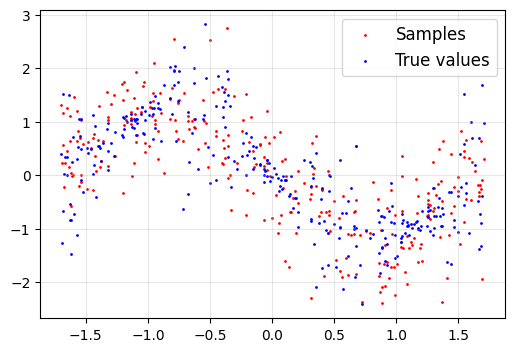

In [152]:
# sample from the model and calculate RMSE
samples = torch.tensor(f_means) + torch.randn_like(torch.tensor(f_means)) * torch.sqrt(torch.tensor(aleatoric_vars))
rmse = torch.sqrt(torch.mean((samples - test_y)**2))
print(f"RMSE: {rmse.item()}")

# plot the samples
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.scatter(test_x, samples, c='r', label='Samples', s=1)
plt.scatter(test_x, test_y, c='b', label='True values', s=1)
plt.legend(fontsize=12)
plt.show()

In [157]:
print(f_vars) # epistemic uncertainty

[0.00441372 0.00418043 0.00393677 0.00390422 0.00368547 0.00351721
 0.00309634 0.00296545 0.00270778 0.00250518 0.00250351 0.00239468
 0.00229865 0.00227666 0.00206542 0.00196683 0.00174534 0.00170875
 0.001616   0.00159484 0.00148392 0.00147808 0.00145245 0.00143504
 0.00134945 0.00124466 0.00122881 0.00118947 0.0011729  0.00116849
 0.00116748 0.00116003 0.00115812 0.00115645 0.00115681 0.00115728
 0.00115848 0.00116134 0.00117087 0.00117123 0.00117147 0.00117242
 0.00117624 0.00117826 0.0011785  0.00117046 0.00116873 0.00116712
 0.00116605 0.00116515 0.00116086 0.0011577  0.00114524 0.00114352
 0.00114179 0.00114125 0.00113487 0.00113255 0.00113147 0.00112599
 0.00112534 0.00112468 0.0011245  0.00111127 0.00110745 0.00110495
 0.00110304 0.00110066 0.0011003  0.0010913  0.00108999 0.00108612
 0.00108457 0.00108433 0.00108314 0.001082   0.00108171 0.00107884
 0.00107831 0.00107741 0.00107622 0.00107288 0.00106972 0.00107032
 0.00106776 0.00106663 0.00106651 0.00106579 0.0010649  0.0010

In [159]:
# get average 
print(np.mean(f_vars))

0.0012845459


In [178]:
np.sqrt(0.00128)

0.03577708763999664

In [158]:
print(aleatoric_vars)

[0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128
 0.42293128 0.42293128 0.42293128 0.42293128 0.42293128 0.4229

In [108]:
# calcualte average true noise variance
true_noise_var = noise_std(test_x)**2
true_noise_var.mean()

tensor(0.3644)

# Heteroscedastic Noise

In [160]:
def f(x): # True function
    return 1 + np.sin(2 * np.pi * x)
def noise_std(x): # Heteroscedastic noise
    return 0.5 + 0.4 * np.cos(6 * np.pi * x)

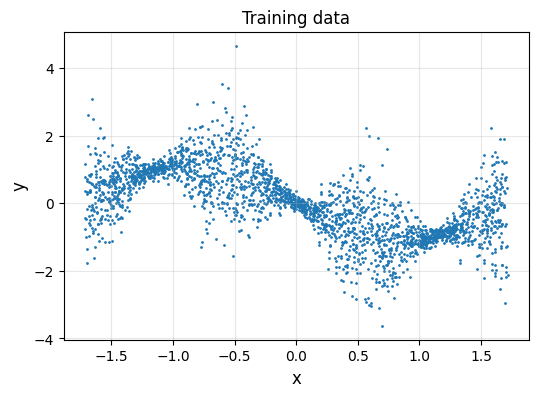

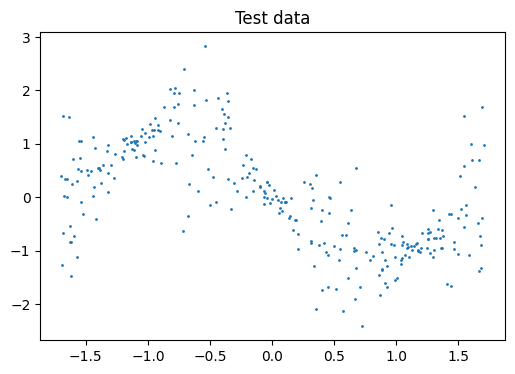

In [161]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
import torch
from dataset import DiffusionDataset, get_dataloader

dataset = DiffusionDataset(dataset_name='sin_1d', n_samples=3000, seed=42, x_normalise=True, y_normalise=True)
x_scalar, y_scalar = dataset.get_scalers()
train_loader, test_loader, val_loader = get_dataloader(dataset, batch_size=32, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)

# Get all x,y pairs from train_loader
train_x = []
train_y = []
for batch in train_loader:
    train_x.append(batch['X'])
    train_y.append(batch['y'])
train_x = torch.cat(train_x).squeeze()
train_y = torch.cat(train_y).squeeze()

# Get all x,y pairs from test_loader
test_x = []
test_y = []
for batch in test_loader:
    test_x.append(batch['X'])
    test_y.append(batch['y'])
test_x = torch.cat(test_x).squeeze()
test_y = torch.cat(test_y).squeeze()

# sort the pairs of train_x and train_y in ascending order based on train_x
sorted_indices = np.argsort(train_x)
train_x = train_x[sorted_indices]
train_y = train_y[sorted_indices]

plt.figure(figsize=(6, 4))
plt.scatter(train_x, train_y, s=1)
plt.title('Training data')
plt.grid(alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.figure(figsize=(6, 4))
plt.scatter(test_x, test_y, s=1)
plt.title('Test data')
plt.show()

In [162]:
# Define models for mean and noise variance
class MeanGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(MeanGP, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

class NoiseGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(NoiseGP, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        # Use a positive constraint on the scale parameter to ensure positive variance
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(),
            outputscale_constraint=gpytorch.constraints.Positive()
        )
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        # The MultivariateNormal distribution ensures positive variance by construction
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [163]:
# Step 1: Train the mean GP model
# Initialize likelihood and model
mean_likelihood = gpytorch.likelihoods.GaussianLikelihood()
mean_model = MeanGP(train_x, train_y, mean_likelihood)

# Training mode
mean_model.train()
mean_likelihood.train()
mean_optimizer = torch.optim.Adam([
    {'params': mean_model.parameters()},
], lr=0.01)

# Loss function: marginal log likelihood
mean_mll = gpytorch.mlls.ExactMarginalLogLikelihood(mean_likelihood, mean_model)

# Training iterations
training_iterations = 100
for i in range(training_iterations):
    # Zero gradients
    mean_optimizer.zero_grad()
    
    # Output from model
    output = mean_model(train_x)
    
    # Calculate loss and backpropagate
    loss = -mean_mll(output, train_y)
    loss.backward()
    mean_optimizer.step()
    
    if (i+1) % 20 == 0:
        print(f'Mean GP - Iter {i+1}/{training_iterations} - Loss: {loss.item():.3f}')

Mean GP - Iter 20/100 - Loss: 1.023
Mean GP - Iter 40/100 - Loss: 1.005
Mean GP - Iter 60/100 - Loss: 0.997
Mean GP - Iter 80/100 - Loss: 0.994
Mean GP - Iter 100/100 - Loss: 0.994


/opt/anaconda3/envs/dgp/lib/python3.11/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


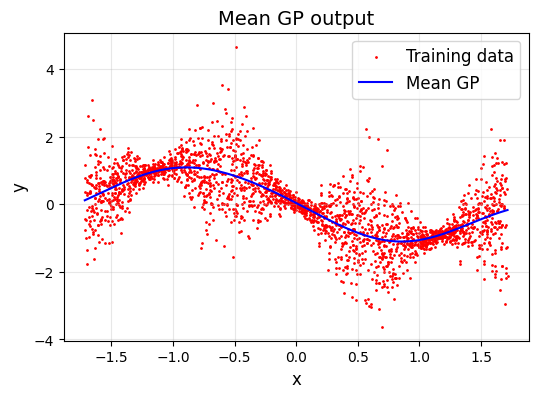

In [164]:
# Set the mean model to evaluation mode
mean_model.eval()
mean_likelihood.eval()
with torch.no_grad():
    mean_pred = mean_model(train_x).mean

plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.scatter(train_x, train_y, c='r', label='Training data', s=1)
plt.plot(train_x, mean_pred, c='b', label='Mean GP')
plt.legend(fontsize=12)
plt.title('Mean GP output', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

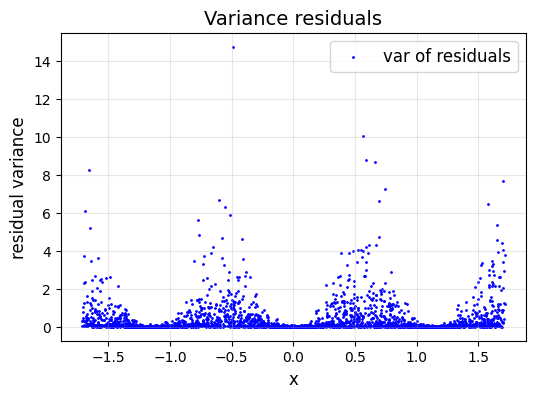

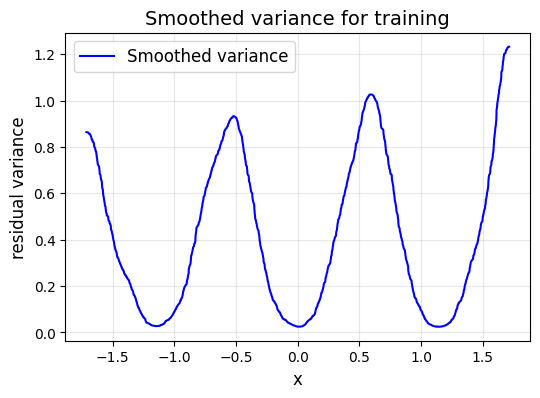

In [165]:
train_var = (train_y - mean_pred)**2
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.scatter(train_x, train_var, c='b', label='var of residuals', s=1)
# plt.plot(train_x, noise_std(train_x)**2, c='r', label='True var')
plt.title('Variance residuals', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('residual variance', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.show()

# smooth the variance
from scipy.ndimage import gaussian_filter
train_var = gaussian_filter(train_var, sigma=50)
train_var = torch.tensor(train_var)
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.plot(train_x, train_var, 'b-', label='Smoothed variance')
plt.title('Smoothed variance for training', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('residual variance', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.show()

Noise GP - Iter 20/100 - Loss: 0.901
Noise GP - Iter 40/100 - Loss: 0.742
Noise GP - Iter 60/100 - Loss: 0.642
Noise GP - Iter 80/100 - Loss: 0.559
Noise GP - Iter 100/100 - Loss: 0.480


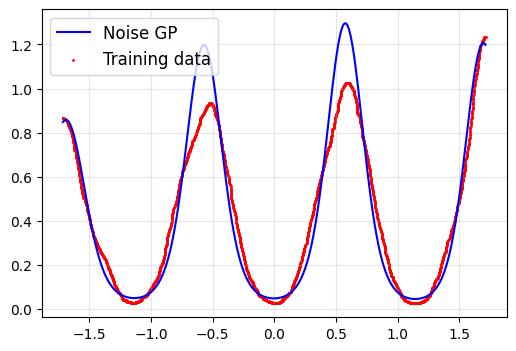

In [166]:
noise_likelihood = gpytorch.likelihoods.GaussianLikelihood()
train_log_var = torch.log(train_var)
noise_model = NoiseGP(train_x, train_log_var, noise_likelihood)
noise_model.train()
noise_likelihood.train()

noise_optimizer = torch.optim.Adam([
    {'params': noise_model.parameters()},
], lr=0.01)
noise_mll = gpytorch.mlls.ExactMarginalLogLikelihood(noise_likelihood, noise_model)

training_iterations = 100
for i in range(training_iterations):
    noise_optimizer.zero_grad()
    output = noise_model(train_x)
    loss = -noise_mll(output, train_log_var)
    loss.backward()
    noise_optimizer.step()

    if (i+1) % 20 == 0:
        print(f'Noise GP - Iter {i+1}/{training_iterations} - Loss: {loss.item():.3f}')

noise_model.eval()
noise_likelihood.eval()

# Plot the results
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.plot(train_x, torch.exp(noise_model(train_x).mean).detach().numpy(), 'b-', label='Noise GP')
plt.scatter(train_x, train_var, c='r', label='Training data', s=1)
plt.legend(fontsize=12)
plt.show()

/var/folders/sq/_ygl92r55ks2__x_h38qg7h00000gn/T/ipykernel_15044/4235652069.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred_y = mean_pred + torch.randn_like(torch.tensor(test_y)) * std_pred


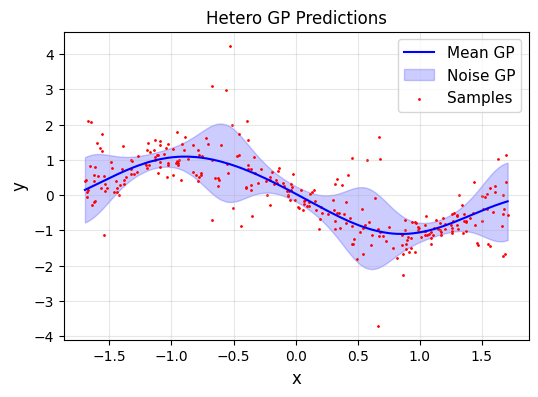

RMSE: 0.8468466997146606


In [167]:
mean_model.eval()
mean_likelihood.eval()
noise_model.eval()
noise_likelihood.eval()
sorted_indices = np.argsort(test_x)
test_x = test_x[sorted_indices]
test_y = test_y[sorted_indices]

# make predictions
with torch.no_grad():
    mean_pred = mean_model(test_x).mean
    log_var_pred = noise_model(test_x).mean
    var_pred = torch.exp(log_var_pred)
    std_pred = torch.sqrt(var_pred)

# plot the results
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.plot(test_x, mean_pred, 'b-', label='Mean GP')
plt.fill_between(test_x, mean_pred - std_pred, mean_pred + std_pred, color='b', alpha=0.2, label='Noise GP')

# # scale the predictions
pred_y = mean_pred + torch.randn_like(torch.tensor(test_y)) * std_pred
plt.scatter(test_x, pred_y, c='r', label='Samples', s=1)
plt.title('Hetero GP Predictions')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=11)
plt.show()

# calculate RMSE
rmse = torch.sqrt(torch.mean((pred_y - test_y)**2))
print(f"RMSE: {rmse.item()}")

In [177]:
np.sqrt(0.0013)

0.03605551275463989

In [174]:
# get total epistemic uncertainty
mean_epi = mean_model(test_x).variance
noise_epi = noise_model(test_x).variance
total_epi = mean_epi + noise_epi

print(torch.mean(total_epi))
print(torch.mean(mean_epi))
print(torch.mean(noise_epi))

tensor(0.0027, grad_fn=<MeanBackward0>)
tensor(0.0013, grad_fn=<MeanBackward0>)
tensor(0.0014, grad_fn=<MeanBackward0>)
